<a href="https://colab.research.google.com/github/jasonhan0916/helloworld/blob/main/ASRM441F25_Project_Jiachen_Han.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ASRM 441 F25 Project**

In [ ]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Load dataset
from google.colab import drive
drive.mount('/gdrive')
!ls /gdrive/My\ Drive/Colab\ Notebooks
life=pd.read_csv('/gdrive/My Drive/Colab Notebooks/441_project/UNLifeExpectancy.csv', delimiter=',', encoding='latin1')
life

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
 441_project		   hail_era5			      Untitled
 CNN_model.py		   hrrr_dataset.ipynb		      Untitled0.ipynb
'cwru python'		   main.py			      Untitled1.ipynb
 hail_data		   noaa_hail_data_exploration.ipynb   Untitled2.ipynb
 hail_data_analysis	   readme.txt			      video1.webm
 hail_dataanalysis.ipynb   state.xlsx			      week_9.ipynb
'hail data.ipynb'	   storm_data_search_results.csv


,REGION,COUNTRY,LIFEEXP,ILLITERATE,POP,FERTILITY,PRIVATEHEALTH,PUBLICEDUCATION,HEALTHEXPEND,BIRTHATTEND,PHYSICIAN,SMOKING,RESEARCHERS,GDP,FEMALEBOSS
0,4,Afghanistan,42.9,72.0,25.1,7.5,3.7,NaN,19.0,14.0,19.0,NaN,NaN,7.3,NaN
1,7,Albania,76.2,1.3,3.2,2.2,3.7,2.9,339.0,98.0,131.0,60.0,NaN,8.4,NaN
2,1,Algeria,71.7,30.1,32.9,2.5,1.0,NaN,167.0,96.0,113.0,32.0,NaN,102.3,NaN
3,6,Angola,41.7,32.6,16.1,6.8,0.4,2.6,38.0,45.0,8.0,NaN,NaN,32.8,NaN
4,3,Antigua and Barbuda,73.9,14.2,0.1,NaN,1.4,3.8,516.0,100.0,17.0,NaN,NaN,0.9,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3,Venezuela (Bolivarian Republic of),73.2,7.0,26.7,2.7,2.7,NaN,285.0,95.0,194.0,NaN,NaN,140.2,27.0
181,2,Viet Nam,73.7,9.7,85.0,2.3,4.0,NaN,184.0,85.0,53.0,35.0,115.0,52.4,22.0
182,1,Yemen,61.5,45.9,21.1,6.0,3.1,9.6,82.0,27.0,33.0,NaN,NaN,15.1,4.0
183,6,Zambia,40.5,32.0,11.5,5.6,2.9,2.0,63.0,43.0,12.0,16.0,51.0,7.3,NaN


#i.a


## Purpose of the National Life Expectancy Dataset

The primary purpose of this dataset is to compare different health care systems help us learn about approaches other than our own, which in turn help us make better decisions in designing improved systems.

## Explanation of Each Variable:

*   **REGION**: Categorical variable for region of the world

*   **COUNTRY**: The name of the country.

*   **LIFEEXP**: Life Expectancy at birth, in years.

*   **ILLITERATE**: Adult illiteracy rate, % aged 15 and older

*   **POP**: 2005 population, in millions

*   **FERTILITY**: Total fertility rate, births per woman

*   **PRIVATEHEALTH**: 2004 Private expenditure on health, % of GDP

*   **PUBLICEDUCATION**: Public expenditure on education, % of GDP

*   **HEALTHEXPEND**: 2004 Health expenditure per capita, PPP in USD

*   **BIRTHATTEND**: Births attended by skilled health personnel (%)

*   **PHYSICIAN**: Physicians per 100,000 people.

*   **SMOKING**: Prevalence of smoking, (male) % of adults.

*   **RESEARCHERS**: Researchers in R & D, per million people.

*   **GDP**: Gross domestic product, in billions of USD.

*   **FEMALEBOSS**: Legislators, senior officials and managers, % female.

# i.b

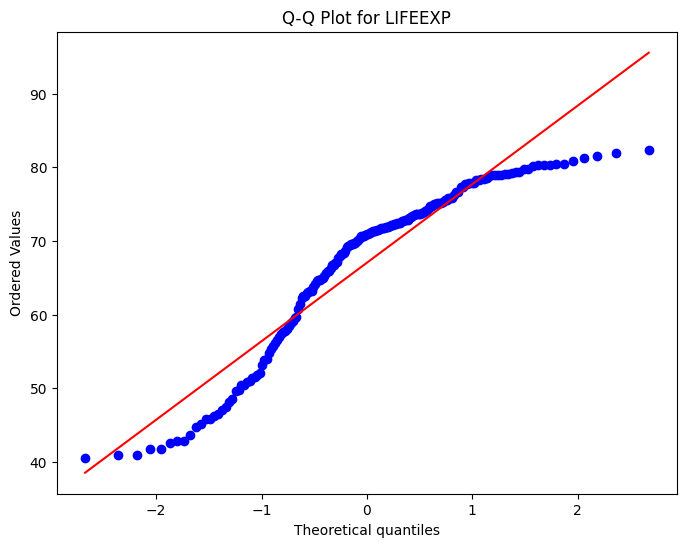

In [ ]:

# Create the QQ plot for 'LIFEEXP'
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
stats.probplot(life['LIFEEXP'], dist="norm", plot=ax)
ax.set_title("Q-Q Plot for LIFEEXP")
plt.show()

**No, the distribution of LIFEEXP is not normally distributed. The points generally follow the diagonal line in the middle, but there are some deviations, particularly at the lower and upper ends.**



#i.c

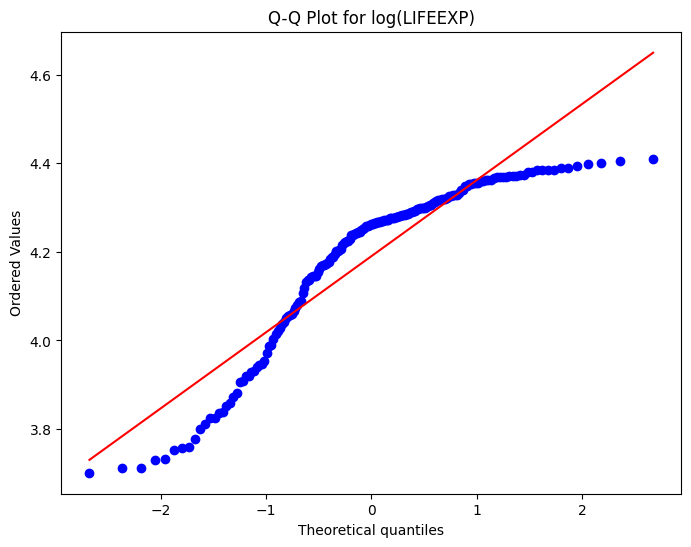

In [ ]:
# Apply natural log transformation to 'LIFEEXP'
life['log_LIFEEXP'] = np.log(life['LIFEEXP'])

# Create the QQ plot for 'log_LIFEEXP'
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
stats.probplot(life['log_LIFEEXP'], dist="norm", plot=ax)
ax.set_title("Q-Q Plot for log(LIFEEXP)")
plt.show()

**No, the log transformation didn't make the distribution of life expectancy much more symmetric and closer to a normal distribution.**

# ii.a

In [ ]:
# Create the linear regression model lmFER
lmFER = smf.ols('LIFEEXP ~ FERTILITY', data=life).fit()

# Print the model summary to inspect results (optional)
print(lmFER.summary())

# Create a DataFrame for prediction for the US FERTILITY rate (2.0)
us_fertility = pd.DataFrame({'FERTILITY': [2.0]})

# Determine the fitted life expectancy for the US
fitted_lifeexp_us = lmFER.predict(us_fertility)
print(f"\nFitted life expectancy for the US (FERTILITY=2.0): {fitted_lifeexp_us.iloc[0]:.2f}")

# Provide a 95% prediction interval for the life expectancy in the US
# For prediction intervals, we use get_prediction() and then summary_frame()
predictions = lmFER.get_prediction(us_fertility)
prediction_interval = predictions.summary_frame(alpha=0.05)

print("\n95% Prediction Interval for US Life Expectancy (FERTILITY=2.0):")
print(f"Lower Bound: {prediction_interval['obs_ci_lower'].iloc[0]:.2f}")
print(f"Upper Bound: {prediction_interval['obs_ci_upper'].iloc[0]:.2f}")

                            OLS Regression Results                            
Dep. Variable:                LIFEEXP   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     333.7
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           9.28e-43
Time:                        02:02:27   Log-Likelihood:                -597.79
No. Observations:                 181   AIC:                             1200.
Df Residuals:                     179   BIC:                             1206.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     83.7381      1.044     80.220      0.0

**The fitted life expectancy is 73.19. The lower bound is 60.08, and the upper bound is 86.30.**

# ii.b

In [ ]:
# China's data
china_fertility = 1.7
china_lifeexp_actual = 72.5

# Create a DataFrame for prediction for China
china_data = pd.DataFrame({'FERTILITY': [china_fertility]})

# Predict life expectancy for China using lmFER
fitted_lifeexp_china = lmFER.predict(china_data)

# Calculate the residual
residual_china = china_lifeexp_actual - fitted_lifeexp_china.iloc[0]

# Get the residual standard error (s) from the model summary
# lmFER.mse_resid is Mean Squared Error of the residuals, s is sqrt(MSE)
s_resid = lmFER.mse_resid**0.5

# Determine how many multiples of s the residual is from zero
multiples_of_s = residual_china / s_resid

print(f"Fitted life expectancy for China (FERTILITY={china_fertility}): {fitted_lifeexp_china.iloc[0]:.2f}")
print(f"Actual life expectancy for China: {china_lifeexp_actual}")
print(f"Residual for China: {residual_china:.2f}")
print(f"Residual standard error (s): {s_resid:.2f}")
print(f"China's residual is {multiples_of_s:.2f} multiples of s from zero.")

Fitted life expectancy for China (FERTILITY=1.7): 74.77
Actual life expectancy for China: 72.5
Residual for China: -2.27
Residual standard error (s): 6.61
China's residual is -0.34 multiples of s from zero.


**The residual is -2.27. The residual is -0.34 multiples of s from zero.**

# ii.c

In [ ]:
# Extract the estimated FERTILITY slope and its standard error from lmFER
estimated_slope = lmFER.params['FERTILITY']
std_err_slope = lmFER.bse['FERTILITY']

# Hypothesized slope for the null hypothesis (H0: beta = -6.0)
hypothesized_slope = -6.0

# Degrees of freedom
df = lmFER.df_resid

# Calculate the t-statistic
t_statistic = (estimated_slope - hypothesized_slope) / std_err_slope

# For a one-sided test (H_A: beta > -6.0) at 5% significance level (alpha = 0.05)
# We look for the critical t-value that leaves 5% in the upper tail
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha, df)

# Calculate the p-value for the one-sided test
# This is the probability of observing a t-statistic as extreme or more extreme (in the positive direction)
p_value = 1 - stats.t.cdf(t_statistic, df)

print(f"Estimated FERTILITY slope: {estimated_slope:.4f}")
print(f"Standard error of slope: {std_err_slope:.4f}")
print(f"Hypothesized slope (H0): {hypothesized_slope}")
print(f"Degrees of freedom: {df}")
print(f"Calculated t-statistic: {t_statistic:.4f}")
print(f"Critical t-value (alpha={alpha}, df={df}, one-sided upper tail): {t_critical:.4f}")
print(f"Approximate p-value: {p_value:.4f}")

# Decision rule
print("\n--- Hypothesis Test Decision ---")
if t_statistic > t_critical:
    print(f"Since t-statistic ({t_statistic:.4f}) > t-critical ({t_critical:.4f}), we reject the null hypothesis.")
    print("Or, since p-value ({p_value:.4f}) < alpha ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is sufficient evidence to suggest that the FERTILITY slope is greater than -6.0.")
else:
    print(f"Since t-statistic ({t_statistic:.4f}) <= t-critical ({t_critical:.4f}), we fail to reject the null hypothesis.")
    print(f"Or, since p-value ({p_value:.4f}) >= alpha ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is not sufficient evidence to suggest that the FERTILITY slope is greater than -6.0.")

Estimated FERTILITY slope: -5.2735
Standard error of slope: 0.2887
Hypothesized slope (H0): -6.0
Degrees of freedom: 179.0
Calculated t-statistic: 2.5164
Critical t-value (alpha=0.05, df=179.0, one-sided upper tail): 1.6534
Approximate p-value: 0.0064

--- Hypothesis Test Decision ---
Since t-statistic (2.5164) > t-critical (1.6534), we reject the null hypothesis.
Or, since p-value ({p_value:.4f}) < alpha ({alpha}), we reject the null hypothesis.
Conclusion: There is sufficient evidence to suggest that the FERTILITY slope is greater than -6.0.


**Since t-statistic (2.5164) > t-critical (1.6534), we reject the null hypothesis, and there is sufficient evidence to suggest that the FERTILITY slope is greater than -6.0. The approximate p-value is 0.0064.**


# iii.a

In [ ]:
# Create the natural logarithmic transform of PRIVATEHEALTH
# Add a small constant (e.g., 1e-9) to PRIVATEHEALTH to avoid log(0) if necessary,
# but it's often better to handle NaN or 0 values more explicitly if they exist.
# Given the data preview, PRIVATEHEALTH seems to be positive, so direct log is fine.
life['lnHEALTH'] = np.log(life['PRIVATEHEALTH'])

lm_data = life[['LIFEEXP','FERTILITY','PUBLICEDUCATION','lnHEALTH']].dropna()
lmEXP = smf.ols("LIFEEXP ~ FERTILITY + PUBLICEDUCATION + lnHEALTH", data=lm_data).fit()
print(lmEXP.summary())

                            OLS Regression Results                            
Dep. Variable:                LIFEEXP   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     89.64
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           4.08e-33
Time:                        02:02:27   Log-Likelihood:                -501.53
No. Observations:                 152   AIC:                             1011.
Df Residuals:                     148   BIC:                             1023.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          85.6264      2.003     

#iii.b

**The estimated coefficient for PUBLICEDUCATION is -0.1846, which means, for every one-unit increase in PUBLICEDUCATION, the LIFEEXP is predicted to decrease by approximately 0.1846 years.**


**The estimated coefficient for lnHEALTH is -1.0296, which means, for a 1% increase in PRIVATEHEALTH, LIFEEXP is predicted to decrease by approximately 1.0296 * ln(1.01) = 0.0102 years**

#iii.c

**1. Null and Alternative Hypotheses:**
*   **Null Hypothesis (H₀):** The true coefficient for `PUBLICEDUCATION` is zero (β_PUBLICEDUCATION = 0). This suggests that `PUBLICEDUCATION` has no linear relationship with `LIFEEXP` when accounting for `FERTILITY` and `lnHEALTH`.
*   **Alternative Hypothesis (H₁):** The true coefficient for `PUBLICEDUCATION` is not zero (β_PUBLICEDUCATION ≠ 0). This suggests that `PUBLICEDUCATION` does have a linear relationship with `LIFEEXP` when accounting for `FERTILITY` and `lnHEALTH`.


**2. Decision-Making Criterion:**
*   We will use a **5% level of significance (α = 0.05)**.
*   We compare the p-value associated with the `PUBLICEDUCATION` coefficient to our chosen significance level (α).

**3. Decision-Making Rule:**
*   If the p-value < α, we reject the null hypothesis.
*   If the p-value ≥ α, we fail to reject the null hypothesis.

**4. Decision:**
*   The p-value for `PUBLICEDUCATION` is 0.493.
*   Since 0.493 (p-value) ≥ 0.05 (α), we **fail to reject the null hypothesis**.

**5. Conclusion:**
*   Based on this analysis, there is **not sufficient statistical evidence** at the 5% level of significance to conclude that `PUBLICEDUCATION` is a statistically significant variable in predicting `LIFEEXP` when `FERTILITY` and `lnHEALTH` are included in the model.

#iii.d

### **Purpose of an Added Variable Plot (AVP):**

An Added Variable Plot visually represents the unique relationship between the dependent variable (in our case, `LIFEEXP`) and a specific independent variable (`PUBLICEDUCATION`), after the effects of all other independent variables already in the model (`FERTILITY` and `lnHEALTH`) have been accounted for.

Its primary purposes include:

1.  **Visualizing Partial Relationships:** It effectively isolates and displays the residual relationship between `LIFEEXP` and `PUBLICEDUCATION` that is *not* explained by the other predictors (`FERTILITY` and `lnHEALTH`).
2.  **Detecting Influential Observations:** It can highlight data points that exert a disproportionate influence on the estimated coefficient of the specific independent variable being examined.
3.  **Identifying Multicollinearity Issues:** If the relationship shown in the AVP is weak or changes significantly compared to a simple bivariate plot, it might signal multicollinearity, where the independent variable is highly correlated with other predictors, making its unique contribution difficult to ascertain.
4.  **Understanding Unexpected Coefficient Signs:** It helps clarify why a coefficient might have an unexpected sign (like the negative sign for `PUBLICEDUCATION`). The coefficient in a multiple regression represents the *partial* effect, which can differ significantly from the simple bivariate correlation.

### **Method for Producing an Added Variable Plot:**

To construct an Added Variable Plot for `PUBLICEDUCATION` in our model (`LIFEEXP ~ FERTILITY + PUBLICEDUCATION + lnHEALTH`), you would conceptually follow these steps:

1.  **Regress the Dependent Variable on All Other Predictors:** First, perform a regression of `LIFEEXP` on all independent variables *except* `PUBLICEDUCATION`. In our case, this would be `LIFEEXP ~ FERTILITY + lnHEALTH`. The residuals from this regression are collected; these represent the variation in `LIFEEXP` that remains unexplained by `FERTILITY` and `lnHEALTH`.

2.  **Regress the Target Predictor on All Other Predictors:** Next, perform a second regression, this time with `PUBLICEDUCATION` as the dependent variable and all other independent variables (`FERTILITY` and `lnHEALTH`) as predictors. Collect the residuals from this second regression. These residuals capture the variation in `PUBLICEDUCATION` that is not explained by `FERTILITY` and `lnHEALTH`.

3.  **Plot the Residuals:** Finally, create a scatter plot where the y-axis represents the residuals from step 1 (of `LIFEEXP`) and the x-axis represents the residuals from step 2 (of `PUBLICEDUCATION`). The slope of the line fitted through these points in this plot will be precisely the coefficient of `PUBLICEDUCATION` obtained from your original multiple regression model (`lmEXP`). The spread of the points around this line indicates the strength and nature of this partial relationship.

#iii.e

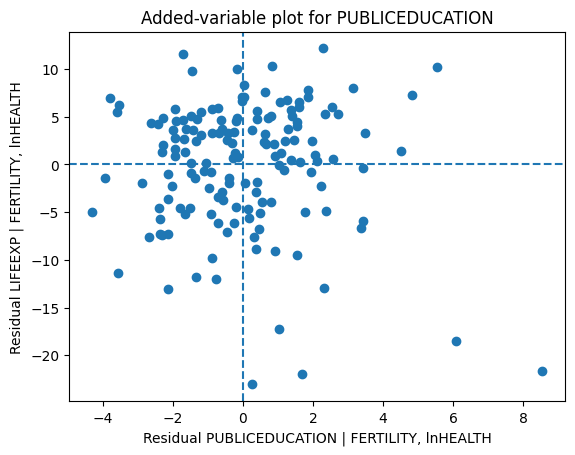

Correlation for added-variable plot (PUBLICEDUCATION): -0.05642316495650949


In [ ]:
res_y_model = smf.ols("LIFEEXP ~ FERTILITY + lnHEALTH", data=lm_data).fit()
res_y = res_y_model.resid

res_x_model = smf.ols("PUBLICEDUCATION ~ FERTILITY + lnHEALTH", data=lm_data).fit()
res_x = res_x_model.resid



plt.scatter(res_x, res_y)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("Residual PUBLICEDUCATION | FERTILITY, lnHEALTH")
plt.ylabel("Residual LIFEEXP | FERTILITY, lnHEALTH")
plt.title("Added-variable plot for PUBLICEDUCATION")
plt.show()

corr_added = np.corrcoef(res_x, res_y)[0,1]
print("Correlation for added-variable plot (PUBLICEDUCATION):", corr_added)


**The correlation corresponding to the Added Variable Plot for PUBLICEDUCATION is -0.0564.**

#iii.f


In [ ]:
# Create the reduced model (excluding PUBLICEDUCATION and lnHEALTH)
lmReduced = smf.ols('LIFEEXP ~ FERTILITY', data=lm_data).fit()

# Perform the F-test using anova_lm to compare the full and reduced models
anova_results = sm.stats.anova_lm(lmReduced, lmEXP)

print(anova_results)

   df_resid          ssr  df_diff    ss_diff         F    Pr(>F)
0     150.0  6602.674213      0.0        NaN       NaN       NaN
1     148.0  6535.724158      2.0  66.950054  0.758034  0.470397




**1. Null and Alternative Hypotheses:**
*   **Null Hypothesis (H₀):** The coefficients for `PUBLICEDUCATION` and `lnHEALTH` are both zero (β_PUBLICEDUCATION = 0 and β_lnHEALTH = 0). This suggests that `PUBLICEDUCATION` and `lnHEALTH` jointly have no linear relationship with `LIFEEXP` when `FERTILITY` is already in the model.
*   **Alternative Hypothesis (H₁):** At least one of the coefficients for `PUBLICEDUCATION` or `lnHEALTH` is not zero. This suggests that `PUBLICEDUCATION` and/or `lnHEALTH` contribute significantly to the model when `FERTILITY` is present.

**2. Decision-Making Criterion:**
*   We will use a **5% level of significance (α = 0.05)**.

**3. Decision-Making Rule:**
*   If the p-value of the F-test < α, we reject the null hypothesis.
*   If the p-value of the F-test ≥ α, we fail to reject the null hypothesis.

**4. Decision:**
*   Since 0.4704 (p-value) ≥ 0.05 (α), we **fail to reject the null hypothesis**.

**5. Conclusion:**
*   Based on this F-test, there is **not sufficient statistical evidence** at the 5% level of significance to conclude that `PUBLICEDUCATION` and `lnHEALTH` are jointly statistically significant in predicting `LIFEEXP` when `FERTILITY` is already included in the model.

#iv

In [ ]:
# Fit the regression model with REGION as a categorical factor
lmREGION = smf.ols('LIFEEXP ~ C(REGION)', data=life).fit()

# Print the model summary
print(lmREGION.summary())

                            OLS Regression Results                            
Dep. Variable:                LIFEEXP   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.648
Method:                 Least Squares   F-statistic:                     49.42
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           1.95e-38
Time:                        02:02:27   Log-Likelihood:                -606.78
No. Observations:                 185   AIC:                             1230.
Df Residuals:                     177   BIC:                             1255.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         69.5476      1.434     48.

**1. Null and Alternative Hypotheses:**
*   **Null Hypothesis (H₀):** All coefficients for the dummy variables representing `REGION` are jointly equal to zero (β_REGION2 = β_REGION3 = ... = β_REGION7 = 0). This implies that `REGION` has no statistically significant effect on `LIFEEXP`.
*   **Alternative Hypothesis (H₁):** At least one of the coefficients for the `REGION` dummy variables is not zero. This implies that `REGION` does have a statistically significant effect on `LIFEEXP`.

**2. Decision-Making Criterion:**
*   We will use a **5% level of significance (α = 0.05)**.

**3. Decision-Making Rule:**
*   We will examine the F-statistic and its corresponding p-value (Prob (F-statistic)) from the model summary.
*   If the p-value < α, we reject the null hypothesis.
*   If the p-value ≥ α, we fail to reject the null hypothesis.

**4. Decision:**
*   From the `lmREGION` model summary, the overall F-statistic is 49.42, and its corresponding p-value (Prob (F-statistic)) is **1.95e-38**.
*   Since the p-value (1.95e-38) is much smaller than α (0.05), we **reject the null hypothesis**.

**5. Conclusion:**
*   Based on this F-test, there is **sufficient statistical evidence** at the 5% level of significance to conclude that `REGION` is a statistically significant determinant of `LIFEEXP`. This indicates that the different regions have a significant effect on life expectancy.

#v.a

In [ ]:
multi_cols = ['LIFEEXP','FERTILITY','PUBLICEDUCATION','lnHEALTH','REGION', 'COUNTRY'] # Added 'COUNTRY'
multi_data = life[multi_cols].dropna()

lm_full_region = smf.ols("LIFEEXP ~ FERTILITY + PUBLICEDUCATION + lnHEALTH + C(REGION)", data=multi_data).fit()
print(lm_full_region.summary())

# New country
new_arab = pd.DataFrame({'FERTILITY':[2.0],'PUBLICEDUCATION':[5.0],'lnHEALTH':[1.0],'REGION':[1]})
new_ssa  = pd.DataFrame({'FERTILITY':[2.0],'PUBLICEDUCATION':[5.0],'lnHEALTH':[1.0],'REGION':[6]})

pred_arab = lm_full_region.get_prediction(new_arab).summary_frame(alpha=0.05)
pred_ssa  = lm_full_region.get_prediction(new_ssa).summary_frame(alpha=0.05)
pred_arab, pred_ssa

                            OLS Regression Results                            
Dep. Variable:                LIFEEXP   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     57.76
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           6.85e-45
Time:                        02:02:27   Log-Likelihood:                -456.47
No. Observations:                 152   AIC:                             934.9
Df Residuals:                     141   BIC:                             968.2
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          83.3971      2.431     

(       mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
 0  74.92505  1.548421      71.863928      77.986173     64.460726   
 
    obs_ci_upper  
 0     85.389374  ,
        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
 0  60.56835  1.668628      57.269587      63.867112     50.032059   
 
    obs_ci_upper  
 0     71.104641  )

In [ ]:
# New country
new_arab = pd.DataFrame({'FERTILITY':[2.0],'PUBLICEDUCATION':[5.0],'lnHEALTH':[1.0],'REGION':[1]})
new_ssa  = pd.DataFrame({'FERTILITY':[2.0],'PUBLICEDUCATION':[5.0],'lnHEALTH':[1.0],'REGION':[6]})

pred_arab = lm_full_region.get_prediction(new_arab).summary_frame(alpha=0.05)
pred_ssa  = lm_full_region.get_prediction(new_ssa).summary_frame(alpha=0.05)
pred_arab, pred_ssa

(       mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
 0  74.92505  1.548421      71.863928      77.986173     64.460726   
 
    obs_ci_upper  
 0     85.389374  ,
        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
 0  60.56835  1.668628      57.269587      63.867112     50.032059   
 
    obs_ci_upper  
 0     71.104641  )

For these predictions, we assumed the following REGION codes:

*   **Arab State:** REGION code 1
*   **Sub-Saharan Africa:** REGION code 6

Here are the predicted life expectancy values:

*   **For a hypothetical country in an Arab state (REGION=1):**
    *   Predicted Life Expectancy (mean): 74.93 years
    *   95% Prediction Interval: [64.46 years, 85.39 years]

*   **For a hypothetical country in sub-Saharan Africa (REGION=6):**
    *   Predicted Life Expectancy (mean): 60.57 years
    *   95% Prediction Interval: [50.03 years, 71.10 years]

#v.b

In [ ]:
import patsy

design_info = lm_full_region.model.data.design_info
X_arab = patsy.build_design_matrices([design_info], new_arab)[0]
X_ssa  = patsy.build_design_matrices([design_info], new_ssa)[0]

beta = lm_full_region.params.values
cov = lm_full_region.cov_params().values

x_diff = X_arab - X_ssa
diff_mean = float(x_diff @ beta)
diff_var  = float(x_diff @ cov @ x_diff.T)
diff_se   = diff_var**0.5

df_resid = lm_full_region.df_resid
crit_t = stats.t.ppf(0.975, df_resid)

ci_lower = diff_mean - crit_t*diff_se
ci_upper = diff_mean + crit_t*diff_se

diff_mean, (ci_lower, ci_upper)

/tmp/ipython-input-857032726.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  diff_mean = float(x_diff @ beta)
/tmp/ipython-input-857032726.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  diff_var  = float(x_diff @ cov @ x_diff.T)


(14.35670024590828,
 (np.float64(10.667225438069082), np.float64(18.04617505374748)))

**The 95% confidence interval for the difference in life expectancies between an Arab state and a country from sub-Saharan Africa lies between 10.67 and 18.05 years.**

#v.c

In [ ]:
# OLS point estimate for difference between sub-Saharan Africa (6) and high-income OECD (8)
d6 = lm_full_region.params['C(REGION)[T.6]']
d8 = lm_full_region.params['C(REGION)[T.8]']
diff_ssa_oecd = d6 - d8
diff_ssa_oecd

np.float64(-18.188634283157242)

**Sub-Saharan African countries have, on average, 18.2 fewer years of life expectancy than High-income OECD countries controlling for other variables.**

#vi.a

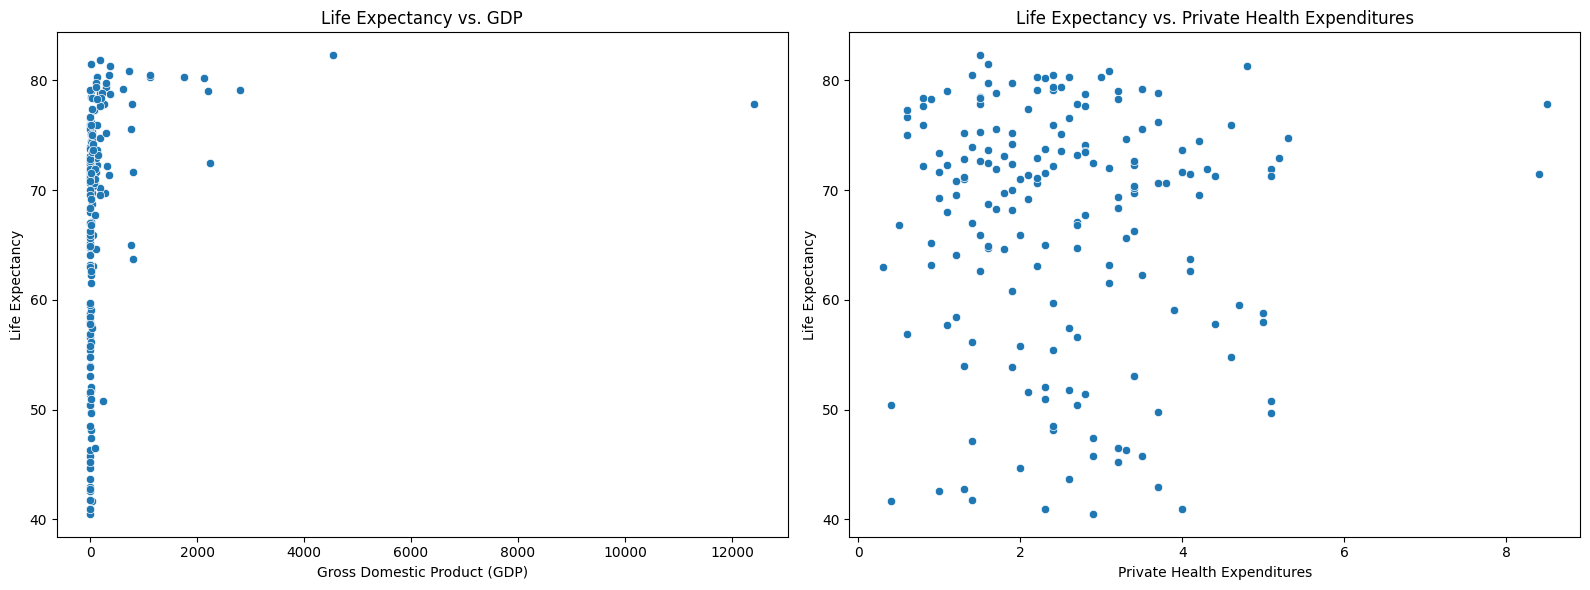

In [ ]:
# Filter data to include only countries with valid (non-missing) life expectancies
data_valid_lifeexp = life.dropna(subset=['LIFEEXP']).copy()

# Create subplots for the initial scatter plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot LIFEEXP vs GDP
sns.scatterplot(x='GDP', y='LIFEEXP', data=data_valid_lifeexp, ax=axes[0])
axes[0].set_title('Life Expectancy vs. GDP')
axes[0].set_xlabel('Gross Domestic Product (GDP)')
axes[0].set_ylabel('Life Expectancy')

# Plot LIFEEXP vs PRIVATEHEALTH
sns.scatterplot(x='PRIVATEHEALTH', y='LIFEEXP', data=data_valid_lifeexp, ax=axes[1])
axes[1].set_title('Life Expectancy vs. Private Health Expenditures')
axes[1].set_xlabel('Private Health Expenditures')
axes[1].set_ylabel('Life Expectancy')

plt.tight_layout()
plt.show()

From the plots of `Life Expectancy vs. GDP` and `Life Expectancy vs. Private Health Expenditures`:

*   **Life Expectancy vs. GDP:** The relationship appears non-linear, often showing a sharp increase in life expectancy at lower GDPs, which then flattens out as GDP increases. The data points are heavily clustered towards the lower end of the GDP scale, indicating a highly skewed distribution for GDP. A logarithmic transformation of GDP (lnGDP) would help to spread out these clustered values, making the relationship more linear and easier to model with linear regression.

*   **Life Expectancy vs. Private Health Expenditures:** Similar to GDP, the data for `PRIVATEHEALTH` is also likely to be skewed, with many countries having low expenditures and a few having very high ones. The plot might show a similar non-linear, possibly curvilinear, relationship where the effect of private health expenditures on life expectancy might diminish at higher levels. Applying a logarithmic transform to `PRIVATEHEALTH` (lnHEALTH) would normalize its distribution, mitigate the effect of outliers, and potentially linearize its relationship with life expectancy.


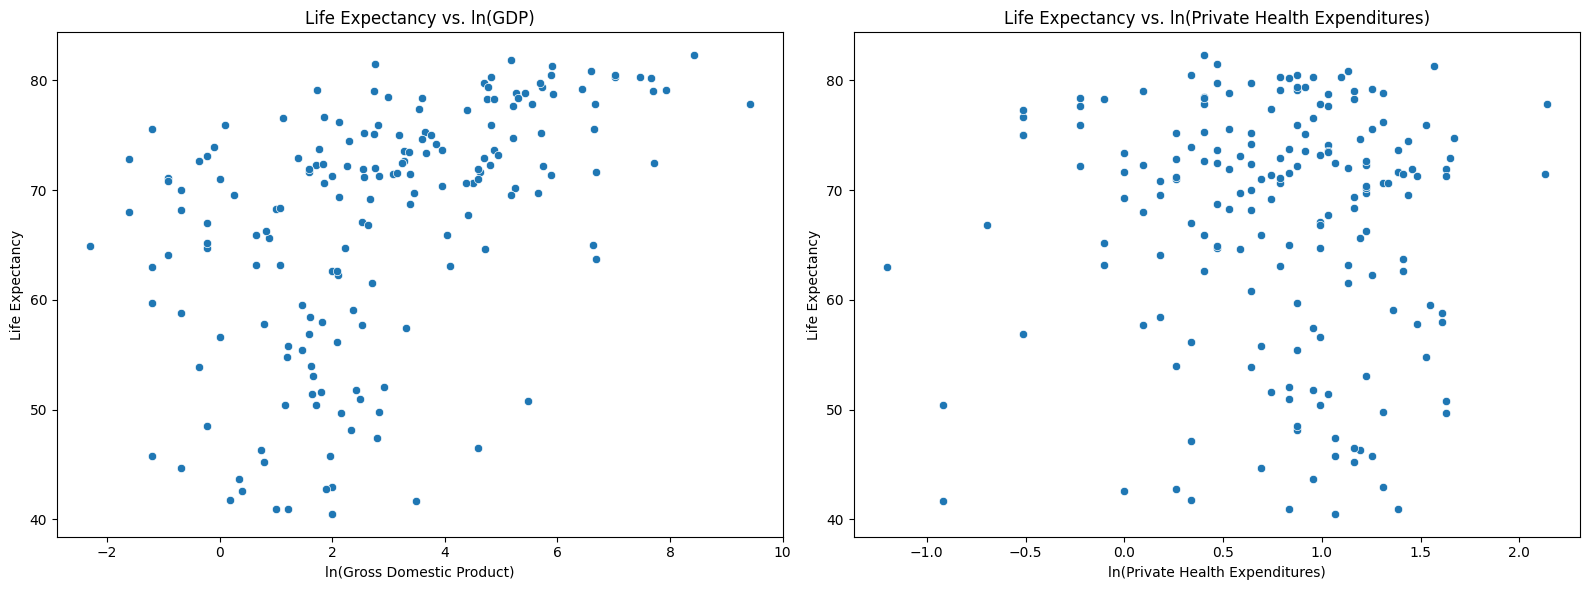

In [ ]:
# Create logarithmic transforms
# Add 1 to GDP to avoid log(0) if any GDP values are 0 or negative, though typically GDP is positive.
data_valid_lifeexp['lnGDP'] = np.log(data_valid_lifeexp['GDP'])
# lnHEALTH was already created in a previous step, but ensure it's available in this filtered dataframe
data_valid_lifeexp['lnHEALTH'] = np.log(data_valid_lifeexp['PRIVATEHEALTH'])

# Create subplots for the log-transformed scatter plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot LIFEEXP vs lnGDP
sns.scatterplot(x='lnGDP', y='LIFEEXP', data=data_valid_lifeexp, ax=axes[0])
axes[0].set_title('Life Expectancy vs. ln(GDP)')
axes[0].set_xlabel('ln(Gross Domestic Product)')
axes[0].set_ylabel('Life Expectancy')

# Plot LIFEEXP vs lnHEALTH
sns.scatterplot(x='lnHEALTH', y='LIFEEXP', data=data_valid_lifeexp, ax=axes[1])
axes[1].set_title('Life Expectancy vs. ln(Private Health Expenditures)')
axes[1].set_xlabel('ln(Private Health Expenditures)')
axes[1].set_ylabel('Life Expectancy')

plt.tight_layout()
plt.show()

The plots of `Life Expectancy vs. ln(GDP)` and `Life Expectancy vs. ln(Private Health Expenditures)` confirm the intuition that logarithmic transformations are beneficial. Both plots now show a much more linear relationship, with data points more evenly distributed across the x-axis, especially when compared to the initial plots with the untransformed variables. This linearization is advantageous for fitting linear regression models, as it aligns better with the model's assumptions.

#**vi.b**

In [ ]:
# Stepwise selection (AIC-based)

life['lnGDP'] = np.log(life['GDP'] + 1e-9)


candidate_vars = ['ILLITERATE','POP','FERTILITY','PRIVATEHEALTH','PUBLICEDUCATION',
                  'HEALTHEXPEND','BIRTHATTEND','PHYSICIAN','GDP','lnGDP','lnHEALTH']

step_data = life[['LIFEEXP','REGION'] + candidate_vars].copy()
step_data_complete = step_data.dropna()

def stepwise_aic(data, response, predictors, include_region=False):
    remaining = list(predictors)
    selected = []
    current_score = np.inf
    formula_base = response + " ~ 1"
    if include_region:
        formula_base += " + C(REGION)"
    while remaining:
        scores = []
        for cand in remaining:
            formula = formula_base
            if selected:
                formula += " + " + " + ".join(selected)
            formula += " + " + cand
            model = smf.ols(formula, data=data).fit()
            scores.append((model.aic, cand))
        scores.sort()
        best_new_score, best_cand = scores[0]
        if best_new_score < current_score - 1e-6:
            remaining.remove(best_cand)
            selected.append(best_cand)
            current_score = best_new_score
        else:
            break
    final_formula = formula_base
    if selected:
        final_formula += " + " + " + ".join(selected)
    final_model = smf.ols(final_formula, data=data).fit()
    return final_model, selected, current_score

model_no_region, selected_no_region, aic_no_region = stepwise_aic(step_data_complete, "LIFEEXP", candidate_vars, include_region=False)
model_with_region, selected_with_region, aic_with_region = stepwise_aic(step_data_complete, "LIFEEXP", candidate_vars, include_region=True)

print("Without REGION, selected:", selected_no_region)
print(model_no_region.summary())

print("\nWith REGION, selected:", selected_with_region)
print(model_with_region.summary())

Without REGION, selected: ['FERTILITY', 'HEALTHEXPEND', 'PUBLICEDUCATION', 'BIRTHATTEND']
                            OLS Regression Results                            
Dep. Variable:                LIFEEXP   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     68.82
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           8.97e-31
Time:                        02:02:33   Log-Likelihood:                -426.02
No. Observations:                 131   AIC:                             862.0
Df Residuals:                     126   BIC:                             876.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

#vii.a

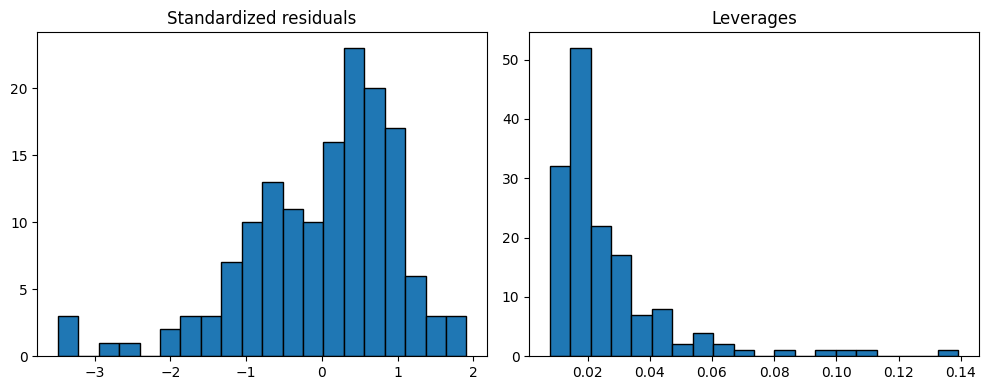

In [ ]:
reg7_data = life[['LIFEEXP','FERTILITY','PUBLICEDUCATION','lnHEALTH']].dropna()
lm7 = smf.ols("LIFEEXP ~ FERTILITY + PUBLICEDUCATION + lnHEALTH", data=reg7_data).fit()
influence = lm7.get_influence()
standardized_resid = influence.resid_studentized_internal
leverage = influence.hat_matrix_diag

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(standardized_resid, bins=20, edgecolor="black")
ax[0].set_title("Standardized residuals")
ax[1].hist(leverage, bins=20, edgecolor="black")
ax[1].set_title("Leverages")
plt.tight_layout()
plt.show()



#vii.b

In [ ]:
# Lesotho
lesotho_idx = reg7_data.index[reg7_data.index.isin(life[life['COUNTRY']=="Lesotho"].index)][0]
lesotho_pos = reg7_data.index.get_loc(lesotho_idx)
lesotho_std_resid = standardized_resid[lesotho_pos]
lesotho_leverage = leverage[lesotho_pos]

print("Lesotho standardized residual:", lesotho_std_resid)
print("Lesotho leverage:", lesotho_leverage)

n = reg7_data.shape[0]
p = lm7.df_model + 1  # incl. intercept
print("2p/n threshold:", 2*p/n)


Lesotho standardized residual: -3.2496737117350487
Lesotho leverage: 0.13922782538356598
2p/n threshold: 0.05263157894736842


Based on the previous analysis:

* Lesotho's **standardized residual** is **-3.25**.
* Lesotho's **leverage** is **0.139**.

Lesotho is **BOTH an outlier and a high-leverage point**. It is an outlier because its standardized residual (absolute value 3.25) is greater than 2, and it is a high-leverage point because its leverage (0.139) is greater than the typical threshold of 2p/n (0.053 in this case).

#vii.c

In [ ]:
# Refit without Lesotho
reg7_no_lesotho = reg7_data.drop(index=lesotho_idx)
lm7_no_lesotho = smf.ols("LIFEEXP ~ FERTILITY + PUBLICEDUCATION + lnHEALTH", data=reg7_no_lesotho).fit()

print("\nOriginal OLS Regression Results (with Lesotho):")
print(lm7.summary())
print("\nOLS Regression Results (without Lesotho):")
print(lm7_no_lesotho.summary())


# Code to find and display the difference
coeff_diff = pd.DataFrame({
    "With_Lesotho": lm7.params,
    "Without_Lesotho": lm7_no_lesotho.params,
    "Difference": lm7_no_lesotho.params - lm7.params
})
print("\nCoefficient Differences:")
print(coeff_diff)



Original OLS Regression Results (with Lesotho):
                            OLS Regression Results                            
Dep. Variable:                LIFEEXP   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     89.64
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           4.08e-33
Time:                        02:02:34   Log-Likelihood:                -501.53
No. Observations:                 152   AIC:                             1011.
Df Residuals:                     148   BIC:                             1023.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

**Key Differences and Implications:**

*   **Intercept (`const`):** The intercept decreases by approximately **1.46 years** when Lesotho is removed. This suggests a general downward shift in the baseline life expectancy when Lesotho is removed.

*   **FERTILITY:** The coefficient for `FERTILITY` changes from **-5.3993 to -5.3075**, a relatively small increase of **0.0917**. While still strongly negative and highly significant in both models, this indicates a slightly less steep negative relationship when Lesotho is excluded.

*   **PUBLICEDUCATION:** This variable shows the most significant change. Its coefficient shifts from **-0.1846 to 0.1403**, representing a difference of **0.3249**. Importantly, the sign of the coefficient *reverses* from negative to positive. In the original model, `PUBLICEDUCATION` was not statistically significant (p-value = 0.493), and its negative sign might have been misleading. Without Lesotho, the coefficient becomes positive (though likely still not statistically significant with p-value = 0.613), suggesting a slight positive association. This dramatic change underscores Lesotho's strong influence on the estimated effect of `PUBLICEDUCATION`.

*   **lnHEALTH:** The coefficient for `lnHEALTH` changes from **-1.0296 to -1.2610**, a decrease of **-0.2315**. This suggests that when Lesotho is removed, the model estimates a slightly stronger negative relationship between the natural logarithm of private health expenditures and life expectancy.